In [1]:
# Install mediapipe

!pip install -q mediapipe


In [2]:
# Download the model

!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task


In [37]:
# Mount drive to upload image

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
# Import dependencies and define functions for landmark

import mediapipe as mp
import numpy as np

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    mp_drawing.draw_landmarks(
      annotated_image,
      hand_landmarks,
      mp_hands.HAND_CONNECTIONS,
      mp_drawing_styles.get_default_hand_landmarks_style(),
      mp_drawing_styles.get_default_hand_connections_style())

    # Get the top left corner of the detected hand's bounding box.
    height, width, _ = annotated_image.shape
    x_coordinates = [landmark.x for landmark in hand_landmarks]
    y_coordinates = [landmark.y for landmark in hand_landmarks]
    text_x = int(min(x_coordinates) * width)
    text_y = int(min(y_coordinates) * height) - MARGIN

    # Draw handedness (left or right hand) on the image.
    cv2.putText(annotated_image, f"{handedness[0].category_name}",
                (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
                FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

  return annotated_image

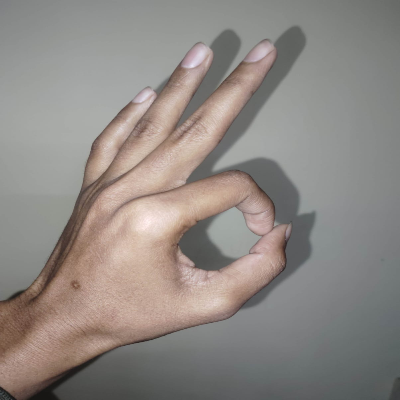

In [49]:
# Upload the image

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/drive/MyDrive/EE655/Assignments/Sample_image_ee655_A2.jpeg')
img = cv2.resize(img,(400,400))
cv2_imshow(img)

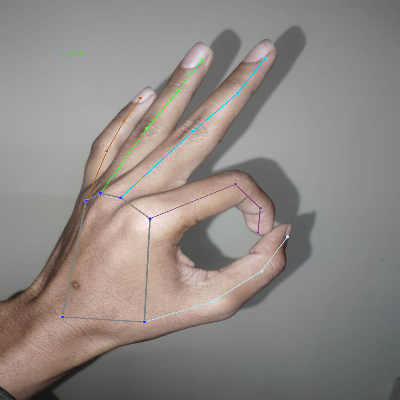

In [50]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("/content/drive/MyDrive/EE655/Assignments/Sample_image_ee655_A2.jpeg")

# STEP 4: Detect hand landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the classification result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
annotated_image = cv2.resize(annotated_image,(400,400))
cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

In [51]:
# defining hough function

def hough_straight_finger(points, finger_ids, H, W, fig_lines):
    """
    points     : list of (x,y) landmark pixel coordinates
    finger_ids : list of 3 landmark indices (top 3 points of a finger)
    """

    # 1. Create blank image
    img = np.zeros((H, W), dtype=np.uint8)

    # 2. Draw finger segments
    p1 = points[finger_ids[0]]
    p2 = points[finger_ids[1]]
    p3 = points[finger_ids[2]]

    cv2.line(img, p1, p2, 255, 3)
    cv2.line(img, p2, p3, 255, 3)

    # 3. Edge detection
    edges = cv2.Canny(img, 50, 150)

    # 4. Hough Line detection
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=25,
        minLineLength=30,
        maxLineGap=8
    )
    fig_lines = fig_lines.append(lines)
    # 5. Decision
    return lines is not None


In [52]:
# Create image having landmarks only in it for hough transform.

import numpy as np
import cv2

H, W, _ = annotated_image.shape

hand_landmarks = detection_result.hand_landmarks[0]

points = []
for lm in hand_landmarks:
    x = int(lm.x * W)
    y = int(lm.y * H)
    points.append((x, y))


In [53]:
# Applying hough transform to check the straight lines over fingers
fig_lines = []

middle_straight = hough_straight_finger(points, [10,11,12], H, W, fig_lines)
ring_straight   = hough_straight_finger(points, [14,15,16], H, W, fig_lines)
small_straight  = hough_straight_finger(points, [18,19,20], H, W, fig_lines)

print("Middle straight:", middle_straight)
print("Ring straight  :", ring_straight)
print("Small straight :", small_straight)


Middle straight: True
Ring straight  : True
Small straight : True


In [54]:
# Creating image with small circles with finger points as center to have eccess to gradients

circle_img = np.zeros((H, W), dtype=np.uint8)

# Index finger + Thumb (top 3)
circle_ids = [5,6, 7, 8, 2, 3, 4]

for i in circle_ids:
    cv2.circle(circle_img, points[i], 15, 255, -1)


In [55]:
# Applying hough transform to detect circles

blur = cv2.GaussianBlur(circle_img, (9, 9), 1.5)

circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,
    param1=100,
    param2=5,     # sensitive → keep low
    minRadius=40,
    maxRadius=50
)


In [56]:
# Drawing circle and lines on the copy of annotated image

output = annotated_image.copy()

# Draw lines
if fig_lines is not None:
    for line in fig_lines:
      for line in line:
            x1, y1, x2, y2 = line[0]
            cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)

# Draw circle
circle_detected = False
if circles is not None:
    circles = np.uint16(np.around(circles))
    for x, y, r in circles[0]:
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        circle_detected = True


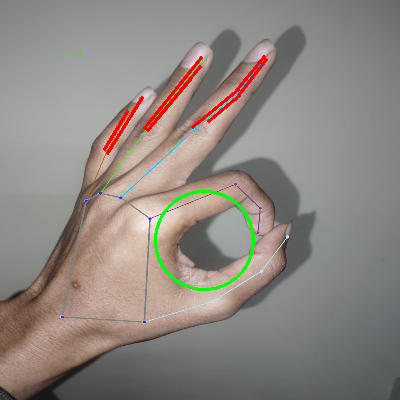

In [57]:
# Showing the image having lines and circle

cv2_imshow(cv2.cvtColor(output, cv2.COLOR_RGB2BGR))


In [47]:
# Final output of the problem.

if circle_detected and middle_straight and ring_straight and small_straight:
    print("✅ WOW / OK Gesture Detected")
else:
    print("❌ NOT a WOW Gesture")



✅ WOW / OK Gesture Detected
